# Classification as simultaneous control

*Introduction to Control and Machine Learning · Part IV: Fusion · Notebook 14*

> **Central question.** *Can one piecewise-constant control steer every training point into the region of its label, what does such a construction cost, and what does it say, and not say, about new data?*

| | |
|---|---|
| **Estimated reading time** (an estimate, not a measurement with students) | CORE ≈ 80–100 min · DEEPER LOOK and RESEARCH WINDOW ≈ 25 min more |
| **Execution time** | about ten seconds |
| **Exercises** | 6 exercises, ≈ 100–140 min |
| **Prerequisites** | [notebook 13](13_resnets_neural_odes.ipynb) (neural ODEs, the E6 classifier and its registered joint evaluation), [notebook 12](12_shallow_networks_representation_sparsity.ipynb) (the 1-D ReLU construction, §2), [notebook 04](04_structured_controls_bangbang_switching.ipynb) (switching controls), [notebook 09](09_machine_learning_foundations_generalization.ipynb) (the protocol) |
| **Source** | Slides `CML_slides_20250520.pdf`, PDF pp. 333–341, 350–362 (see the Source map at the end) |
| **Notation** | `notation.md` §5. $x'=w(t)\sigma(a(t)\cdot x+b(t))$ with $\sigma(z)=\max\{z,0\}$ (ReLU) throughout; $w$ is the outer weight of the field, $\Theta$ all parameters. $N$ is the **total** number of training points (p. 359 writes $N$ per class, $2N$ in total). The slides' $L$ counts switches or layers; here we write "layers" and "switches" in words, and a switch is a jump of the control inside $(0,T)$, so switches $=$ layers $-1$ |

**How to read this notebook.** `CORE` sections give the complete story. `DEEPER LOOK` sections contain proofs of secondary facts, finer comparisons and optional checks. `RESEARCH WINDOW` sections point to advanced material from the slides. Both kinds of section can be skipped, and no CORE cell depends on them. (Cells carry the same labels as machine-readable tags.)

> **First pass through this notebook.**
> *Essential:* the CORE sections §§1–6 (the classification theorem and its hypotheses; the three basic actions of a ReLU neuron, solved exactly; a construction in the plane; counting switches, amplitudes and width; constructed versus trained on new E6 data), Figures 1–3, Exercises 1–2.
> *Deeper study:* the DEEPER LOOK §8 (deep non-residual networks), Exercises 3–4.
> *Research-oriented:* the RESEARCH WINDOW §9 (width, depth, clustering and probability) and the `ADVANCED` Exercises 5–6.

**Learning objectives.** After this notebook you should be able to

1. state the classification theorem of p. 338 with the hypotheses it needs, including those the slide does not print;
2. solve the dynamics of one ReLU neuron with constant control exactly, and recognize the three basic actions;
3. construct a piecewise-constant control that sends every training point of a planar data set into the region of its label, and prove that it works;
4. count switches, control amplitudes and layers, and say how they change with the horizon and the width;
5. explain why exact steering of the training points says nothing, by itself, about new points, and read a pre-registered comparison with a trained network.

## Where are we?
`CORE`

> **Recap.** [Notebook 13](13_resnets_neural_odes.ipynb): a residual network is the Euler scheme of a neural ODE, training is simultaneous optimal control, and the discrete adjoint gives exact gradients. Its E6 classifier was *trained*, with a fixed readout (label $1$ iff $x^{(1)}(T)>1$), and its final evaluation was registered jointly with this notebook. [Notebook 12](12_shallow_networks_representation_sparsity.ipynb), §2: in one dimension, $N$ ReLU neurons interpolate $N$ values through a triangular system.

Control theory asks a sharper question than training does. The slides recall Kalman's theorem (p. 333) and Nelson's car (p. 334): few controls can steer many states. Supervised learning asks to steer *many copies* of the same system, one per data point, with *one* control (p. 336). This notebook asks whether that is possible for neural ODEs, with which controls, and at what cost. It then compares a **constructed** control with the **trained** one of notebook 13, on new data, as registered before either was evaluated.

## 1. The classification theorem and what it assumes
`CORE`

> **Theorem (classification; Ruiz-Balet–Zuazua, *SIAM Review* 2023; p. 338), as printed.** *Consider the NODE with the ReLU as activation function. Then, in any time horizon $[0,T]$, a finite arbitrary number of items can be driven to an arbitrary number of open subsets of the Euclidean space corresponding to its labels.*
> - *Controls are piecewise constant with a maximal number of $O(N)$ switches. They also lie in $BV$.*
> - *The control time $T>0$ can be made arbitrarily small (absorbed into $\|w\|$ by scaling).*
> - *The complexity of controls diminishes when initial data are structured in clusters or the control requirement is relaxed.*

The conclusion is about the **training items only**: their flow map images $\Phi_T(x_i)$ land in the open set attached to their label. Several hypotheses are needed that the slide does not print. We record them, without claiming that this is the exact list of the cited paper.

- **Distinct items, or compatible labels.** $\Phi_T$ is a map, so two identical inputs have the same image. If $x_i=x_j$ with different labels and disjoint target sets, no control can work. Coincident inputs with the same label are harmless. The function `check_compatible` detects the incompatible case.
- **Dimension $d\ge2$.** In one dimension the flow of $x'=f(x,\theta(t))$ preserves order (notebook 13, §8). Take $x_1<x_2<x_3$ with labels $1,0,1$ and targets $\Omega_1=(1,\infty)$, $\Omega_0=(-\infty,1)$: we would need $\Phi_T(x_1)>1>\Phi_T(x_2)$, contradicting $\Phi_T(x_1)<\Phi_T(x_2)$. The statement, as printed, is false for $d=1$; the related results of pp. 355 and 359 do assume $d\ge2$.
- **Non-empty open targets**, one per label. Openness is what allows a margin.
- **The count $O(N)$** is a statement about how the number of switches grows with $N$, for a construction. It is not a lower bound, and its constant is not given.

The second bullet is exact for piecewise-constant controls. Running the same control on $[0,cT]$ with every $w$ divided by $c$ (and times multiplied by $c$) produces the same flow map. A shorter horizon is paid for with larger amplitudes (§4).

> **Predict.** The cell below checks two small data sets for compatibility. Which one cannot be classified by *any* flow?

In [1]:
import sys
from pathlib import Path


def find_repository_root():
    # The shared code lives in CML_notebooks/src/. Search this folder and its parents.
    for folder in [Path.cwd(), *Path.cwd().parents]:
        if (folder / "src" / "control_utils.py").exists():
            return folder
    raise FileNotFoundError(
        "Could not find src/control_utils.py in this folder or any parent folder.\n"
        "Run this notebook from inside the complete CML_notebooks repository "
        "(for example from CML_notebooks/notebooks/), after installing requirements.txt.\n"
        "See README.md, section 'Installation'.")


sys.path.insert(0, str(find_repository_root()))

import numpy as np
import matplotlib.pyplot as plt

from src.ml_utils import make_streams, point_cloud_E6, split_indices, population_E6
from src.node_utils import euler_flow, readout_label, select_residual_classifier
from src.relu_control_utils import (relu_action_exact, check_compatible, construct_classifier, apply_layers,
                                    classify_constructed)
from src.plotting_utils import apply_style, COLORS

apply_style()
np.set_printoptions(precision=4, suppress=True)

# Notebook 14 draws no random numbers of its own. Its only streams are those of the joint 13-14 evaluation
# (reports/protocol_12_16.md, sections 13-14 and 14): "course" reproduces E6 and its split of notebooks 09-11 and 13;
# "joint_eval" is reserved for the joint final sample and is used once, in section 5.
streams, stream_keys = make_streams(1314, ["course", "joint_eval"])
X6, y6 = point_cloud_E6(streams["course"])
train6, val6, test6 = split_indices(len(y6), streams["course"])   # the E6 test split was evaluated in 11: not used
print("stream keys:", stream_keys)

for name, X, y in (("three points, two of them equal with equal labels", [[0, 1], [0, 1], [2, 0]], [1, 1, 0]),
                   ("two equal points with different labels", [[0, 1], [0, 1]], [0, 1])):
    try:
        print(f"{name}: compatible, coinciding pairs {check_compatible(np.array(X, float), np.array(y))}")
    except ValueError as err:
        print(f"{name}: INCOMPATIBLE ({err})")

stream keys: {'course': ('course', 0), 'joint_eval': (1314, 5)}
three points, two of them equal with equal labels: compatible, coinciding pairs [(0, 1)]
two equal points with different labels: INCOMPATIBLE (inputs 0 and 1 coincide but have labels 0 and 1)


## 2. What one ReLU neuron does: three basic actions, solved exactly
`CORE`

Take one neuron with a constant control $(w,a,b)$ on a time interval: $x'=w\,\sigma(a\cdot x+b)$. The slides read it geometrically (p. 339): $a$ and $b$ define the hyperplane $H=\{a\cdot x+b=0\}$; *$\sigma$ "activates" $\{a\cdot x+b>0\}$ and "freezes" $\{a\cdot x+b\le0\}$*; and *$w$ gives the direction of the field inside the active half-space*. The dynamics can be solved in closed form *(the computation is a pedagogical addition)*. Let $s(t)=a\cdot x(t)+b$.

- **Frozen side.** If $s(0)\le0$, then $x(t)=x(0)$ for all $t$. The constant solution satisfies the equation, and it is the only one, since the field is Lipschitz.
- **Active side.** If $s(0)>0$, then as long as $s>0$, $s'=a\cdot x'=(a\cdot w)\,s$. So $s(t)=s(0)e^{(a\cdot w)t}$, which stays positive, and
$$
x(t)=x(0)+w\,s(0)\,\frac{e^{(a\cdot w)t}-1}{a\cdot w}\qquad\Big(\,=x(0)+w\,s(0)\,t\ \text{ if }a\cdot w=0\Big).
$$
Every active point moves on a straight line in the direction $w$. The fraction $(e^{ct}-1)/c$ tends to $t$ as $c\to0$, so the formula is continuous in $a\cdot w$.

The three cases are the three pictures of p. 339:

| $a\cdot w$ | name on p. 339 | effect on the active half-space |
|---|---|---|
| $=0$ | parallel | $s$ is constant: each point slides parallel to $H$, at a speed proportional to its distance from $H$ (a *shear*) |
| $<0$ | contraction | $s\to0$ exponentially: points approach $H$ but never reach it |
| $>0$ | expansion | $s$ grows exponentially: points move away from $H$ |

**No point ever crosses $H$ during one action**, since $s$ keeps its sign. One half-space is left exactly invariant while the other is deformed; the slides stress that this *introduces dynamics not found in mechanics* (p. 340). Crossing a hyperplane requires a change of control, i.e. a switch, i.e. a new layer.

> **Predict.** Apply each of the three actions, for the same hyperplane, to a grid of points. Which points move, and where do they go?

parallel (a.w = 0)     a.w = +0.00: frozen points moved 0.0e+00; sign of s kept: True; |exact - Euler(h = 4e-04)| = 2.2e-13
contraction (a.w < 0)  a.w = -0.90: frozen points moved 0.0e+00; sign of s kept: True; |exact - Euler(h = 4e-04)| = 8.1e-05
expansion (a.w > 0)    a.w = +0.90: frozen points moved 0.0e+00; sign of s kept: True; |exact - Euler(h = 4e-04)| = 3.4e-04


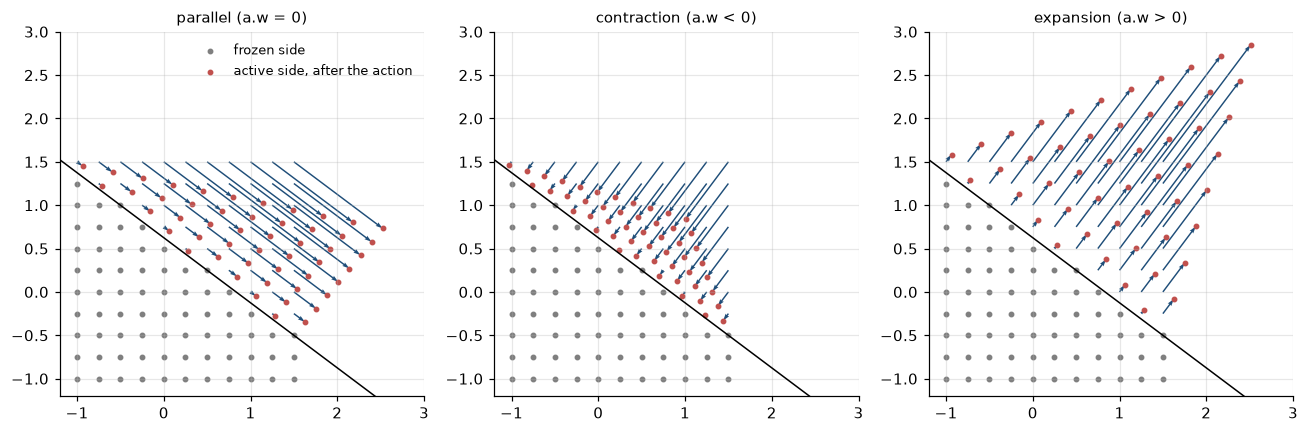

In [2]:
a_H, b_H, t_H = np.array([0.6, 0.8]), -0.5, 0.8                     # hyperplane 0.6 x1 + 0.8 x2 = 0.5
actions = {"parallel (a.w = 0)": np.array([0.8, -0.6]), "contraction (a.w < 0)": -0.9 * a_H,
           "expansion (a.w > 0)": 0.9 * a_H}
grid_pts = np.array([[x, y] for x in np.linspace(-1, 1.5, 11) for y in np.linspace(-1, 1.5, 11)])
s0 = grid_pts @ a_H + b_H
K_check = 2000
fig, axes = plt.subplots(1, 3, figsize=(12, 3.9))
for ax, (name, w) in zip(axes, actions.items()):
    moved = relu_action_exact(grid_pts, w, a_H, b_H, t_H)
    Theta = (np.tile(w[:, None], (K_check, 1, 1)), np.tile(a_H[None, :], (K_check, 1, 1)), np.full((K_check, 1), b_H))
    euler = euler_flow(grid_pts, Theta, t_H / K_check, activation="relu")[-1]
    s_t = moved @ a_H + b_H
    print(f"{name:22s} a.w = {a_H @ w:+.2f}: frozen points moved {np.abs(moved[s0 <= 0] - grid_pts[s0 <= 0]).max():.1e}; "
          f"sign of s kept: {bool(np.all((s_t > 0) == (s0 > 0)))}; |exact - Euler(h = {t_H / K_check:.0e})| = {np.abs(moved - euler).max():.1e}")
    ax.scatter(grid_pts[s0 <= 0, 0], grid_pts[s0 <= 0, 1], s=8, color=COLORS["reference"], label="frozen side")
    ax.quiver(grid_pts[s0 > 0, 0], grid_pts[s0 > 0, 1], *(moved - grid_pts)[s0 > 0].T, angles="xy", scale_units="xy",
              scale=1, width=0.004, color=COLORS["state"])
    ax.scatter(moved[s0 > 0, 0], moved[s0 > 0, 1], s=8, color=COLORS["control"], label="active side, after the action")
    xs = np.linspace(-1.2, 3, 2)
    ax.plot(xs, (-b_H - a_H[0] * xs) / a_H[1], color="black", lw=1)
    ax.set_xlim(-1.2, 3); ax.set_ylim(-1.2, 3); ax.set_aspect("equal"); ax.set_title(name, fontsize=10)
axes[0].legend(fontsize=8.5, loc="upper right")
plt.tight_layout(); plt.show()

**Figure 1.** The three basic actions of one ReLU neuron with constant control, for the same hyperplane $0.6x^{(1)}+0.8x^{(2)}=0.5$ (black line) and duration $0.8$: parallel ($a\cdot w=0$), contraction ($a\cdot w<0$), expansion ($a\cdot w>0$). Grey: points on the frozen side. Arrows: the exact displacement of each active point, from the closed-form solution.

*Interpretation (answer to the prediction).* Points below the line do not move at all (printed: displacement $0$). Every active point moves on a straight line in the direction $w$, and none crosses the line: the sign of $a\cdot x+b$ is preserved (printed). The shear moves points parallel to the line, faster the farther they are from it. The contraction pulls them towards the line, and the expansion pushes them away exponentially. The closed form agrees with a fine Euler simulation (the ReLU network of notebook 13) to the printed $O(h)$ accuracy.

## 3. A construction in the plane
`CORE`

The slides prove the theorem by *one step + induction* (p. 341): move one point where it must go, without disturbing the others, and repeat. We give a **simpler construction of our own** *(pedagogical addition)*. It is specific to $d=2$ and to the half-plane targets of p. 359, $\Omega_1=\{x^{(1)}>1\}$ and $\Omega_0=\{x^{(1)}<1\}$, with a margin. It uses only the parallel action.

**Ingredients.** Take $a=e_2$ and $w=v\,e_1$, so $a\cdot w=0$. The action $x'=v\,e_1\,\sigma(x^{(2)}-\beta)$ freezes the points with height $x^{(2)}\le\beta$ and moves the others horizontally, each at the constant speed $v\,(x^{(2)}-\beta)$. **Heights never change.** Every action is horizontal, so all actions see the same heights, and their horizontal displacements simply add up.

**The construction.** Let the $N$ training points have distinct heights $h_1<\dots<h_N$, after sorting.
1. Place a knot $\beta_1<h_1$ and knots $\beta_j=\frac12(h_{j-1}+h_j)$ for $j\ge2$.
2. Layer $j$ is the action with knot $\beta_j$ and speed $v_j$, for a time $\tau=T/N$. It moves exactly the points $j,\dots,N$ and leaves $1,\dots,j-1$ frozen.
3. After all layers, point $i$ has moved horizontally by $D(h_i)$, where
$$
D(h)=\tau\sum_{j=1}^Nv_j\,\sigma(h-\beta_j).
$$
4. Ask $D(h_i)=c_{y_i}-x_i^{(1)}$, with the target positions $c_1=1.5$ and $c_0=0.5$. Since $\sigma(h_i-\beta_j)=0$ for $j>i$ and $h_i-\beta_i>0$, this is a **lower-triangular system with positive diagonal**: a unique solution, by forward substitution.

This is the 1-D construction of notebook 12, §2, applied to the height variable.

> **Proposition (construction).** *Assumptions:* $N$ points in $\mathbb R^2$ with distinct heights, labels in $\{0,1\}$, targets $c_0<1<c_1$. *Conclusion:* the $N$ parallel actions above send every point to first coordinate exactly $c_{y_i}$, i.e. into $\Omega_{y_i}$ with margin $\min(c_1-1,1-c_0)$, with $N$ constant segments (layers), hence at most $N-1$ switches (adjacent identical pieces could be merged; `construct_classifier` counts the actual changes), on any horizon $T>0$.

*Proof.* Heights are invariant and the frozen sets are exactly as described, so the final first coordinate of point $i$ is $x_i^{(1)}+D(h_i)=c_{y_i}$ by the triangular system. $\square$

**Distinct heights are not a real restriction.** If two distinct points share a height, they differ in the first coordinate. One preliminary parallel action along $e_2$, active everywhere, then changes their heights by different amounts; `construct_classifier` does this and counts the extra layer. Identical points with different labels are rejected (§1). Other directions work too: with $a=(\sin\varphi,\cos\varphi)$ and $w\perp a$, "heights" are measured along $a$.

> **Predict.** For the seven points below, whose labels alternate with height, how many layers will be needed, and what will a point that lies *between* two training heights do?

 layer   knot beta   speed v    points moved (by height rank)
     1      -1.400      14.000    [1, 2, 3, 4, 5, 6, 7]
     2      -0.100     -46.667    [2, 3, 4, 5, 6, 7]
     3       0.325     -63.467    [3, 4, 5, 6, 7]
     4       0.575     293.067    [4, 5, 6, 7]
     5       0.825    -477.867    [5, 6, 7]
     6       1.075     685.067    [6, 7]
     7       1.350    -938.933    [7]
layers 7, switches 6, largest speed 938.93, int |w| dt = 359.87
every point in the region of its label: True   margin 0.500
two new points between training heights end at x1 = [-1.8167 -4.8167]


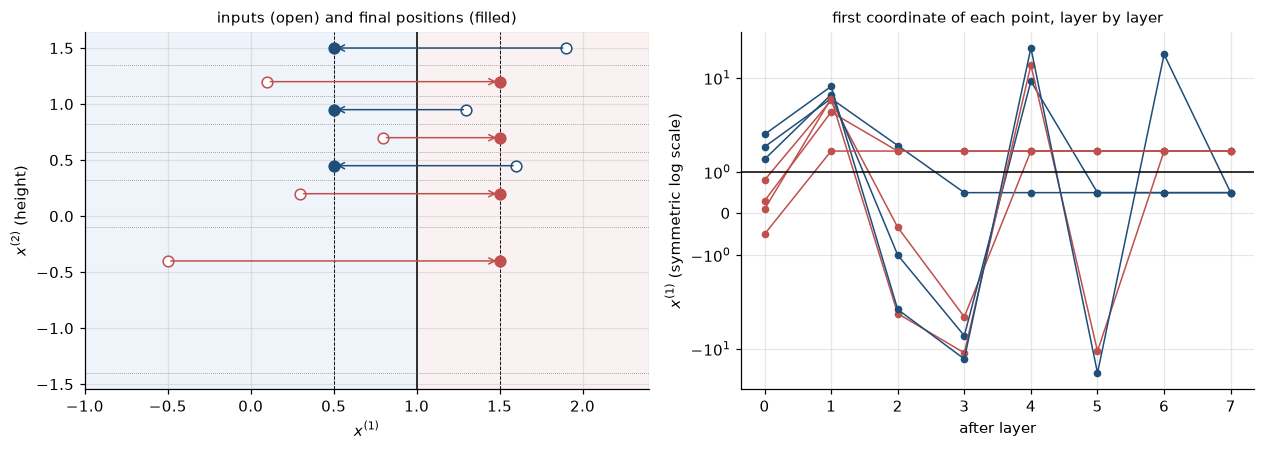

In [3]:
X_core = np.array([[0.3, 0.2], [1.6, 0.45], [0.8, 0.7], [1.3, 0.95], [0.1, 1.2], [1.9, 1.5], [-0.5, -0.4]])
y_core = np.array([1, 0, 1, 0, 1, 0, 1])
clf_core = construct_classifier(X_core, y_core, phi=0.0, targets=(0.5, 1.5), T=1.0)
positions = [X_core]
print(" layer   knot beta   speed v    points moved (by height rank)")
rank = np.argsort(np.argsort(X_core[:, 1]))
for k, (kind, A, U, b, v, tau) in enumerate(clf_core["layers"]):
    moving = np.where(positions[-1] @ A[0] + b[0] > 0)[0]
    print(f"{k + 1:6d}   {-b[0]:9.3f}   {v[0]:9.3f}    {sorted(int(r) + 1 for r in rank[moving])}")
    positions.append(apply_layers(positions[-1], [(kind, A, U, b, v, tau)]))
final_core = positions[-1]
margin_core = np.min((final_core[:, 0] - 1) * (2 * y_core - 1))
print(f"layers {clf_core['n_layers']}, switches {clf_core['switches']}, largest speed {clf_core['max_speed']:.2f}, "
      f"int |w| dt = {clf_core['l1_in_time']:.2f}")
print("every point in the region of its label:", bool(np.all(readout_label(final_core) == y_core)), f"  margin {margin_core:.3f}")

new_points = np.array([[1.0, 0.575], [1.0, 1.075]])                  # between two training heights
print("two new points between training heights end at x1 =", apply_layers(new_points, clf_core["layers"])[:, 0])

path = np.array(positions)                                           # (layers + 1, N, 2)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.6, 4.2), gridspec_kw={"width_ratios": [1.1, 1]})
ax1.axvspan(1, 2.4, color=COLORS["control"], alpha=0.07); ax1.axvspan(-1.0, 1, color=COLORS["state2"], alpha=0.10)
ax1.axvline(1, color="black", lw=1); ax1.axvline(0.5, color="black", lw=0.6, ls="--"); ax1.axvline(1.5, color="black", lw=0.6, ls="--")
for kind, A, U, b, v, tau in clf_core["layers"]:
    ax1.axhline(-b[0], color=COLORS["reference"], lw=0.5, ls=":")
for i in range(len(X_core)):
    c = COLORS["control"] if y_core[i] == 1 else COLORS["state"]
    ax1.annotate("", xy=final_core[i], xytext=X_core[i], arrowprops=dict(arrowstyle="->", color=c, lw=1))
    ax1.plot(*X_core[i], "o", color=c, mfc="white", ms=7); ax1.plot(*final_core[i], "o", color=c, ms=7)
    ax2.plot(np.arange(len(path)), path[:, i, 0], "o-", color=c, ms=4, lw=1)
ax1.set_xlim(-1.0, 2.4); ax1.set_xlabel("$x^{(1)}$"); ax1.set_ylabel("$x^{(2)}$ (height)")
ax1.set_title("inputs (open) and final positions (filled)", fontsize=10)
ax2.set_yscale("symlog", linthresh=2); ax2.axhline(1, color="black", lw=1)
ax2.set_xlabel("after layer"); ax2.set_ylabel("$x^{(1)}$ (symmetric log scale)")
ax2.set_title("first coordinate of each point, layer by layer", fontsize=10)
plt.tight_layout(); plt.show()

**Figure 2.** The constructed control for seven points whose labels alternate with height (red: label 1; blue: label 0). *Left:* inputs (open circles), final positions (filled) and the net horizontal displacement of each point. Dotted horizontal lines are the knots $\beta_j$ (each layer freezes everything below its knot). The readout line $x^{(1)}=1$ is solid and the targets $c_0=0.5$, $c_1=1.5$ are dashed; shading marks $\Omega_1$ (red) and $\Omega_0$ (blue). *Right:* the first coordinate of each point after each layer, on a symmetric logarithmic scale.

*Interpretation (answer to the prediction).* Seven layers (six switches) suffice. The printed sequence of actions shows that layer $j$ moves only the points from height rank $j$ upwards, so a point, once placed, is never moved again. On the right, the point of height rank $j$ is moved only by layers $1$ to $j$: it overshoots in between, by amounts of order ten here, and from layer $j$ on it stays fixed on its target. Every point ends exactly on its target, with margin $0.5$, and all motion is horizontal. A new point between two training heights is moved by the same piecewise-linear displacement $D$, and ends wherever $D$ sends it: for the two printed points, far to the left of both targets. The construction places the training points; it does not decide sensibly about the points in between.

## 4. Counting: switches, amplitudes, horizon, width
`CORE`

**Switches.** *Convention:* the control is constant on each of its $n$ pieces (layers), and a switch is a time at which it actually changes, so here switches $=n-1$; a preliminary layer, when needed, counts as a piece. The construction uses $N$ layers, so at most $N-1$ switches: $O(N)$, as on p. 338. Each switch changes $(w,a,b)$ at once, a *change of layer* in the language of p. 339. This count is an **upper bound** on the least number of switches needed for the data, not that least number.

**Amplitudes and the horizon.** Halving $T$ halves the duration $\tau$ of every layer, so every speed must double to produce the same displacements. The largest amplitude scales like $1/T$, while the $L^1$ size $\int_0^T|w(t)|\,dt$ is unchanged. *(Both are computed over all pieces, the preliminary one included. With width $P>1$ we report, separately, the largest amplitude of one neuron, the largest spectral norm of the matrix $W=[w_1\cdots w_P]$, and the time integral of the sum of the neuron norms, which coincide for $P=1$.)* This is the precise content of *"$T$ can be made arbitrarily small (absorbed into $\|w\|$ by scaling)"* (p. 338). A short horizon is not free; it is paid for in amplitude.

**Amplitudes and the geometry of the data.** The diagonal entries of the triangular system are the gaps $h_i-\beta_i$, half the distance between consecutive heights. The speeds scale like the inverse gaps. Closely spaced heights with different labels need very large controls.

**Width.** With $P$ neurons per layer, $x'=\sum_{i=1}^Pw_i\sigma(a_i\cdot x+b_i)$, the parallel actions of $P$ consecutive knots can act **simultaneously**, because they move every point horizontally and leave heights unchanged. Grouping them gives $\lceil N/P\rceil$ layers, with **exactly the same final map**. This is a special, commuting case of the trade-off stated on p. 354:

- **Width versus depth (p. 354), as printed.** *Increasing the width allows parallelising the consecutive actions of the switching controls and reducing depth: $O(N)\to O(1+N/p)$ layers.* The theorem behind it (p. 355) concerns **simultaneous control** $\Phi_T(x_i)=y_i$ (interpolation of target points), in dimension $d\ge2$, for pairs of different points. When $d\ge N+1$ the number of layers is $O(N/p)$ (p. 354, footnote; p. 356 writes $d>N$).
- **Classification (p. 359).** For width $1$, two classes of $N$ points each in general position in $\mathbb R^d$ with $2\le d<2N$, the number of switches is $O(1+N/d)$: higher dimension helps.

Our construction does not prove these theorems. It shows the mechanism in a case where the actions commute, which is exactly why width can replace depth there without changing anything.

> **Predict.** For the seven points, what happens to the largest speed and to $\int|w|\,dt$ when $T$ goes from $1$ to $0.1$? How many layers are needed with width $2$, $3$, $7$?

In [4]:
print("   T     largest speed    int |w| dt    max change of the final positions")
for T in (1.0, 0.5, 0.1):
    c = construct_classifier(X_core, y_core, targets=(0.5, 1.5), T=T)
    print(f"{T:5.1f}   {c['max_speed']:13.2f}   {c['l1_in_time']:11.3f}   {np.abs(c['final_train'] - final_core).max():.1e}")
print("width P   layers   switches   max change of the map on a test grid")
test_grid = np.array([[x, y] for x in np.linspace(-1, 2, 7) for y in np.linspace(-0.6, 1.8, 7)])
for P in (1, 2, 3, 7):
    c = construct_classifier(X_core, y_core, targets=(0.5, 1.5), width=P)
    change = np.abs(apply_layers(test_grid, c["layers"]) - apply_layers(test_grid, clf_core["layers"])).max()
    print(f"{P:7d}   {c['n_layers']:6d}   {c['switches']:8d}   {change:.1e}")
heights = np.sort(X_core[:, 1])
print(f"smallest height gap {np.diff(heights).min():.3f} -> largest speed {clf_core['max_speed']:.1f}")

   T     largest speed    int |w| dt    max change of the final positions
  1.0          938.93       359.867   0.0e+00
  0.5         1877.87       359.867   0.0e+00
  0.1         9389.33       359.867   3.6e-15
width P   layers   switches   max change of the map on a test grid
      1        7          6   0.0e+00
      2        4          3   1.8e-14
      3        3          2   7.1e-15
      7        1          0   1.8e-14
smallest height gap 0.250 -> largest speed 938.9


## 5. Laboratory: constructed versus trained, on new E6 data
`CORE`

The construction of §3 applies to any planar data set with compatible labels. Applied to the 72 E6 training points, it is **procedure B** of the joint evaluation registered in notebook 13. Procedure A is the trained residual classifier of notebook 13. Both use the readout of p. 359: label $1$ iff the first coordinate of the final state exceeds $1$.

**Protocol** (`reports/protocol_12_16.md`, sections 13–14 and 14; both frozen before any joint data were generated).

- **Procedure A:** notebook 13's trained classifier, re-run here from its frozen specification. It is deterministic, so it reproduces notebook 13's parameters; its choice was $K=10$, $\alpha=10^{-2}$.
- **Procedure B:** the construction of §3, $T=1$, width $1$, targets $0.5$ and $1.5$, on the training split. The direction $\varphi\in\{0^\circ,30^\circ,60^\circ,120^\circ,150^\circ\}$ in which heights are measured is chosen by validation accuracy (ties to the smaller angle).
- **Joint final sample:** 2000 new, independent observations of the **E6 population law**. Each has a label $\sim$ Bernoulli$(\frac12)$, an angle $\sim U[0,\pi]$ on its half-moon, and the same noise as E6. This is not the fixed-angle design of `point_cloud_E6`. The sample comes from the reserved stream, is drawn once, after both procedures are fixed, and is not used for any choice.
- **Reported:** misclassification rates with Wilson 95% intervals, per-class error rates, and the discordant counts; **no winner is selected on these data**.

> **Predict.** Both procedures classify all 72 training points correctly. Which one will do better on new points, and by how much?

 phi    training acc.   validation acc.   layers   largest speed
   0           1.000             0.458       72        9.36e+05
  30           1.000             0.333       72        9.15e+05
  60           1.000             0.625       72        1.31e+05
 120           1.000             0.625       72        6.52e+05
 150           1.000             0.667       72        1.04e+06  <- B


A: selected (K, alpha) = (10, 0.01), validation accuracy 0.958


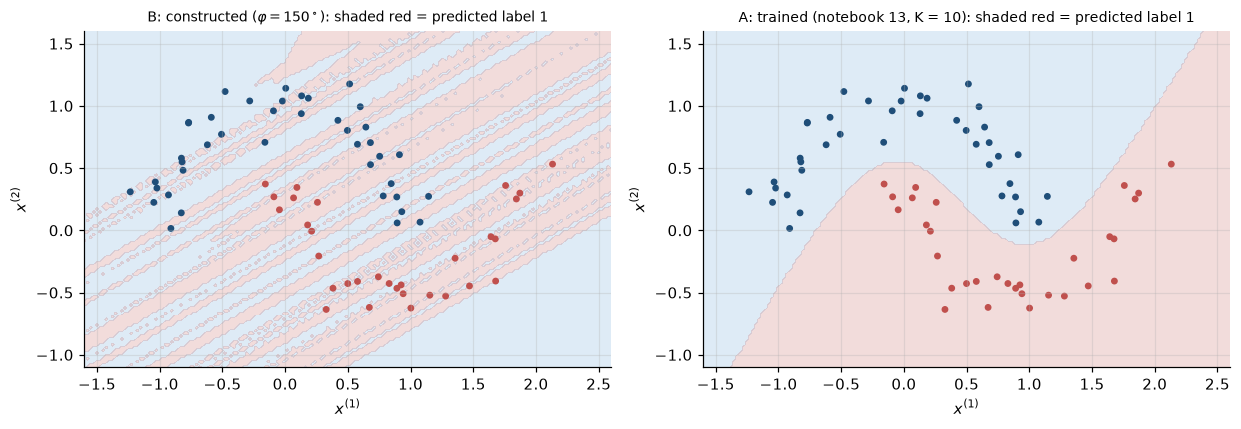

In [5]:
X_tr, y_tr, X_val, y_val = X6[train6], y6[train6], X6[val6], y6[val6]

# Procedure B: the construction of section 3 on the training split; phi chosen on validation accuracy.
phis_deg = [0, 30, 60, 120, 150]
constructions = {deg: construct_classifier(X_tr, y_tr, phi=np.deg2rad(deg), targets=(0.5, 1.5), T=1.0) for deg in phis_deg}
val_acc_B = {deg: float(np.mean(classify_constructed(X_val, c)[0] == y_val)) for deg, c in constructions.items()}
phi_B = min(phis_deg, key=lambda deg: (-val_acc_B[deg], deg))
clf_B = constructions[phi_B]
print(" phi    training acc.   validation acc.   layers   largest speed")
for deg, c in constructions.items():
    tr_acc = np.mean(classify_constructed(X_tr, c)[0] == y_tr)
    print(f"{deg:4d}   {tr_acc:13.3f}   {val_acc_B[deg]:15.3f}   {c['n_layers']:6d}   {c['max_speed']:13.2e}" + ("  <- B" if deg == phi_B else ""))

# Procedure A: the frozen procedure of notebook 13 (protocol section 13), re-run deterministically.
best_A, models_A, table_A = select_residual_classifier(X_tr, y_tr, X_val, y_val, [5, 10, 20], [0.0, 1e-3, 1e-2, 1e-1],
                                                       P=8, T=2.0, n_steps=1000, eta=0.05, scale=4.0)
Theta_A, h_A = models_A[best_A]
print(f"A: selected (K, alpha) = {best_A}, validation accuracy {table_A[best_A]['validation accuracy']:.3f}")

g1, g2 = np.meshgrid(np.linspace(-1.6, 2.6, 170), np.linspace(-1.1, 1.6, 120))
G = np.column_stack([g1.ravel(), g2.ravel()])
regions = {f"B: constructed ($\\varphi={phi_B}^\\circ$)": classify_constructed(G, clf_B)[0].reshape(g1.shape),
           f"A: trained (notebook 13, K = {best_A[0]})": readout_label(euler_flow(G, Theta_A, h_A)[-1]).reshape(g1.shape)}
fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.0))
for ax, (name, reg) in zip(axes, regions.items()):
    ax.contourf(g1, g2, reg, levels=[-0.5, 0.5, 1.5], colors=[COLORS["state2"], COLORS["control"]], alpha=0.2)
    ax.scatter(X_tr[:, 0], X_tr[:, 1], c=np.where(y_tr == 1, COLORS["control"], COLORS["state"]), s=12)
    ax.set_title(name + ": shaded red = predicted label 1", fontsize=9); ax.set_xlabel("$x^{(1)}$"); ax.set_ylabel("$x^{(2)}$")
plt.tight_layout(); plt.show()

**Figure 3.** The input plane, shaded where each procedure predicts label $1$, with the 72 training points coloured by their labels. *Left:* procedure B, the constructed control, with the direction chosen on validation data. *Right:* procedure A, the trained residual network of notebook 13.

*Interpretation (answer to the first part of the prediction).* Both procedures send every training point to the correct side; they disagree everywhere else. The constructed control's decision region is a union of thin bands. Its displacement $D$ interpolates the required displacements of training points whose heights are very close but whose labels differ, so it oscillates violently between them (the printed speeds reach $10^5$–$10^6$). The trained network's region follows the two moons. Its loss and its control cost favoured a moderate deformation, and its parameters were chosen on validation data. Exact steering of the training points is a statement about controllability, not about prediction. The joint evaluation below measures the consequence on new data.

In [6]:
# Joint final evaluation, as registered in reports/protocol_12_16.md (section 13-14), applied once after both
# procedures were frozen: 2000 new observations of the E6 population law from the reserved stream (1314, 5).
X_joint, y_joint = population_E6(streams["joint_eval"], 2000)
pred = {"A (trained, notebook 13)": readout_label(euler_flow(X_joint, Theta_A, h_A)[-1]),
        "B (constructed, this notebook)": classify_constructed(X_joint, clf_B)[0]}


def wilson(k, n, z=1.959964):
    p = k / n
    centre, half = (p + z**2 / (2 * n)) / (1 + z**2 / n), z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / (1 + z**2 / n)
    return centre - half, centre + half


joint1314 = {"stream key": stream_keys["joint_eval"], "n": len(y_joint), "class sizes": np.bincount(y_joint)}
print(f"n = {len(y_joint)} (label 0: {np.sum(y_joint == 0)}, label 1: {np.sum(y_joint == 1)})")
for name, p in pred.items():
    errors = int(np.sum(p != y_joint))
    lo, hi = wilson(errors, len(y_joint))
    per_class = [float(np.mean(p[y_joint == c] != c)) for c in (0, 1)]
    joint1314[name] = {"errors": errors, "error rate": errors / len(y_joint), "Wilson 95%": (lo, hi), "per class": per_class}
    print(f"{name:31s} error rate {errors / len(y_joint):.3f}  [{lo:.3f}, {hi:.3f}]   per class (0, 1): {per_class[0]:.3f}, {per_class[1]:.3f}")
right_A, right_B = pred["A (trained, notebook 13)"] == y_joint, pred["B (constructed, this notebook)"] == y_joint
joint1314["discordant (A right, B wrong)"] = int(np.sum(right_A & ~right_B))
joint1314["discordant (A wrong, B right)"] = int(np.sum(~right_A & right_B))
print(f"discordant observations: A right / B wrong {joint1314['discordant (A right, B wrong)']}, "
      f"A wrong / B right {joint1314['discordant (A wrong, B right)']}")

n = 2000 (label 0: 989, label 1: 1011)
A (trained, notebook 13)        error rate 0.011  [0.007, 0.017]   per class (0, 1): 0.006, 0.016
B (constructed, this notebook)  error rate 0.378  [0.357, 0.399]   per class (0, 1): 0.386, 0.369
discordant observations: A right / B wrong 745, A wrong / B right 12


**Reading the joint evaluation** *(answer to the second part of the prediction)*. On the 2000 new observations, the trained classifier A misclassified 22 (error rate $0.011$, Wilson 95% interval $[0.007,0.017]$). The constructed control B misclassified 755 ($0.378$, interval $[0.357,0.399]$). Per-class rates are printed, and both procedures err about equally on the two classes. Of the observations on which they disagree, 745 are classified correctly by A only and 12 by B only. The two intervals are far apart: for *these two procedures* and *this law*, the difference is much larger than the sampling uncertainty of 2000 observations. It is statistical evidence about this comparison, not a certainty and not a ranking of trained versus constructed controls in general.
- These numbers were computed once, after both procedures had been frozen. Neither procedure was changed afterwards, and no choice in this course depends on them.
- They confirm, on independent data, what the validation accuracies suggested ($23/24$ for A; $16/24$ for B's best direction).
- A control that steers every training point exactly demonstrates capacity. The trained network, whose loss and control cost favour a moderate deformation, generalizes on this task.

Two caveats limit the scope of the comparison. E6 is a low-noise problem in the plane, with a readout that suits it. And B is our simple construction, not the one in the cited paper, whose purpose is existence and complexity, not prediction.

## 6. Control ↔ ML
`CORE`

- **Classification = simultaneous control.** **DIRECT CONNECTION** (pp. 336, 338). One control steers all training points at once, each into the open set of its label. The fixed readout of p. 359 makes the target sets explicit.
- **Layers = switches of a piecewise-constant control.** **DIRECT CONNECTION** (p. 339; notebook 04). A ResNet of ReLU neurons with constant controls on each layer is a switching control, and counting layers is counting switches.
- **Exact steering of training data = interpolation.** **DIRECT CONNECTION** with notebooks 09 and 12. Like the exact-interpolation problem $P_0$ of notebook 12, the construction fits every training point and nothing in it favours sensible behaviour in between. Controllability gives *capacity*; generalization needs a criterion that looks beyond the training points (a loss with a control cost, chosen on validation data, in procedure A).
- **Width versus depth.** **MATHEMATICAL ANALOGY** with parallel versus sequential actuation. Wider layers parallelize consecutive actions (p. 354); in our commuting case exactly, in general only under the hypotheses of the cited theorems.

## 7. Common misconceptions
`CORE`

**"The classification theorem says that neural ODEs classify new data well."** It says that the *training items* can be steered into their target sets. Figure 3 and the joint evaluation show how far that is from prediction.

**"Any labelling can be realized."** Not for identical inputs with different labels, and not in dimension one when the labels are incompatible with the order (§1).

**"A shorter horizon means a cheaper network."** The amplitudes grow like $1/T$; only $\int|w|\,dt$ is unchanged (§4).

**"A point can be pushed across a hyperplane by the neuron that defines it."** During one action, the sign of $a\cdot x+b$ never changes (§2). Crossing needs a switch.

**"Width always replaces depth one for one."** It does so exactly in our commuting construction. In general the trade-off $O(N)\to O(1+N/p)$ is a theorem with hypotheses (§4).

## 8. Deep non-residual networks: collapsing instead of sliding
`DEEPER LOOK`

Without the residual term, a layer is $x_{k+1}=\sigma(a_kx_k+b_k)$, with $a_k\in\mathbb R^{d_{k+1}\times d_k}$ and $\sigma$ applied entrywise (p. 350). Its geometry is different (pp. 351–352). With one hyperplane, *all points on one side collapse to zero*. With two hyperplanes in the plane, the four regions cut out by them are mapped to four different places. The region where both pre-activations are positive is mapped bijectively onto the open quadrant, if $a_k$ is invertible. The two mixed regions are flattened onto the two half-axes. The region where both are $\le0$ is sent to the single point $(0,0)$. A residual layer with small steps is close to invertible; a non-residual ReLU layer is not injective. It *forgets* on purpose, which is how it merges points of the same class.

> **Result (Hernández–Zuazua; p. 350), transcribed.** *A family of $N$ items in $d$ dimensions belonging to $M$ classes can be classified with width $2$ and depth $2N+4M-1$.* (The slide does not state further hypotheses; we do not prove the result.)

The cell below applies one width-2 non-residual layer to a grid, coloured by the sign pattern of the two pre-activations.

both <= 0        :  275 grid points ->    1 distinct images
only the 2nd > 0 :  261 grid points ->  197 distinct images
only the 1st > 0 :  173 grid points ->   30 distinct images
both > 0         :  252 grid points ->  252 distinct images


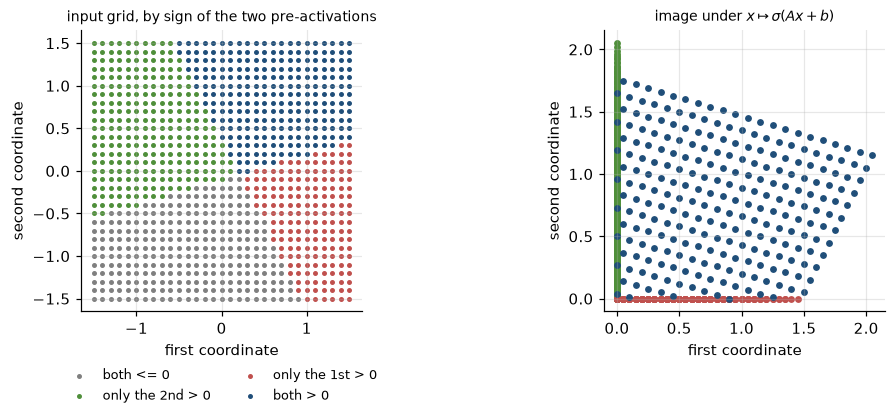

In [7]:
A_nr, b_nr = np.array([[1.0, 0.5], [-0.3, 1.0]]), np.array([-0.2, 0.1])
pts = np.array([[x, y] for x in np.linspace(-1.5, 1.5, 31) for y in np.linspace(-1.5, 1.5, 31)])
pre = pts @ A_nr.T + b_nr
image = np.maximum(pre, 0.0)
pattern = (pre[:, 0] > 0).astype(int) * 2 + (pre[:, 1] > 0).astype(int)    # 0: (-,-), 1: (-,+), 2: (+,-), 3: (+,+)
names = ["both <= 0", "only the 2nd > 0", "only the 1st > 0", "both > 0"]
cols = [COLORS["reference"], COLORS["adjoint"], COLORS["control"], COLORS["state"]]
for k in range(4):
    sel = pattern == k
    print(f"{names[k]:17s}: {sel.sum():4d} grid points -> {len(np.unique(image[sel].round(12), axis=0)):4d} distinct images")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
for k in range(4):
    sel = pattern == k
    ax1.scatter(pts[sel, 0], pts[sel, 1], s=5, color=cols[k], label=names[k])
    ax2.scatter(image[sel, 0], image[sel, 1], s=12, color=cols[k])
ax1.set_title("input grid, by sign of the two pre-activations", fontsize=9)
ax1.legend(fontsize=8.5, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2)
ax2.set_title(r"image under $x\mapsto\sigma(Ax+b)$", fontsize=9)
for ax in (ax1, ax2):
    ax.set_aspect("equal"); ax.set_xlabel("first coordinate"); ax.set_ylabel("second coordinate")
plt.tight_layout(); plt.show()

**Figure 4.** One width-2 non-residual ReLU layer $x\mapsto\sigma(Ax+b)$. *Left:* an input grid coloured by the signs of the two pre-activations. *Right:* its image.

*Interpretation.* The region where both pre-activations are positive is mapped one-to-one onto part of the open quadrant. Each mixed region is flattened onto a half-axis, and the region where both are non-positive collapses to the origin: hundreds of grid points have a single image (printed counts). This is the opposite of the residual layers of §§2–3, which slide points without merging them. Merging is useful for classification, since points of one class can be sent to one place. It is also irreversible, which a flow never is.

## 9. Width, depth, clustering and probability
`RESEARCH WINDOW`

The slides report several refinements, all for neural ODEs with ReLU activation. We transcribe their hypotheses; none is proved here.

- **Simultaneous control with width $p$** (Álvarez-López–Slimane–Zuazua; p. 355). For $d\ge2$ and $N$ pairs of different points, for any $T>0$ there is a piecewise-constant control with $L=O(1+N/p)$ discontinuities such that $\Phi_T(x_i)=y_i$ for all $i$. The proof is described in two steps: control $d-1$ coordinates, then the last one. If $d>N$, $L=O(N/p)$ (p. 356).
- **Autonomous fields** (p. 357). With a constant control of width $p$, $\sup_i|y_i-\Phi_T(x_i)|\le C_{d,N,T,\mathrm{Lip}(V)}\log_2(\kappa)/\kappa^{1/d}$, $\kappa=(d+2)dp$. This is approximate, not exact, control by a very wide autonomous field, linked on p. 354 to turnpike theory.
- **Clustering and dimension** (Álvarez-López–Orive-Illera–Zuazua; pp. 358–359). For binary classification with targets $\{x^{(1)}>1\}$ and $\{x^{(1)}<1\}$, $2\le d<2N$, and two classes of $N$ points in general position, width $1$ and $L=O(1+N/d)$ switches suffice. Clustered data need fewer.
- **Probabilistic statements** (pp. 356, 360) bound the probability that few switches suffice when the points are drawn uniformly in $[0,1]^d$.
- **Other architectures** (pp. 361–362). ReLU powers $\sigma_k(z)=(\max\{z,0\})^k$ give *the same results for simultaneous control* with a smaller static approximation error. Momentum neural ODEs $x''=w\sigma(a\cdot x+b)$ have *the same capacity for simultaneous control, with $O(N)$ neurons*, and two points can share the same position (notebook 13, §9 and Exercise 6). Relaxed neural ODEs replace the sum of neurons by an integral against a probability measure $\mu$ over the parameters (p. 362). The slides note that *the optimization problem becomes linear (in $\mu$)*. What is linear is the **field** $\int w\sigma(a\cdot x+b)\,d\mu$, for a fixed state $x$. The **flow** it generates, and any cost composed with that flow, depend on $\mu$ nonlinearly in general and need not be convex. The static relaxation of notebook 12, §9, where the network output itself is linear in the measure, does not transfer automatically to the dynamic problem.

**An inconsistency we flag (p. 360).** The slide's "linear separability" bound reads $P(L=0)\ge1-\big(\frac{2(N!)^2}{(2N)!}\big)^d$, followed by the asymptotic form $1-\exp\{-\frac{\sqrt{\pi N}}{2^{2N-1}}d\}$. The two do not agree. The number $q_N=\frac{2(N!)^2}{(2N)!}=2/\binom{2N}{N}$ is exactly the probability that $N$ red and $N$ blue i.i.d. points on a line are separated by a threshold (only 2 of the $\binom{2N}{N}$ equally likely colour orders work), and $q_N\approx\frac{\sqrt{\pi N}}{2^{2N-1}}$ by Stirling. The asymptotic form is that of $1-(1-q_N)^d\approx1-e^{-q_Nd}$, the probability that at least one of $d$ independent coordinates separates the classes. The displayed bound $1-q_N^d$ is close to $1$, while $1-e^{-q_Nd}$ is close to $0$ unless $d\gg4^N$. We do not use either formula; the cell below only checks the two numbers that are exact.

In [8]:
from math import comb, factorial, pi, sqrt
for N in (2, 5, 10, 20):
    q = 2 * factorial(N) ** 2 / factorial(2 * N)
    print(f"N = {N:2d}: 2(N!)^2/(2N)! = {q:.3e} = 2/binom(2N, N) = {2 / comb(2 * N, N):.3e};  Stirling sqrt(pi N)/2^(2N-1) = {sqrt(pi * N) / 2 ** (2 * N - 1):.3e}")

N =  2: 2(N!)^2/(2N)! = 3.333e-01 = 2/binom(2N, N) = 3.333e-01;  Stirling sqrt(pi N)/2^(2N-1) = 3.133e-01
N =  5: 2(N!)^2/(2N)! = 7.937e-03 = 2/binom(2N, N) = 7.937e-03;  Stirling sqrt(pi N)/2^(2N-1) = 7.741e-03
N = 10: 2(N!)^2/(2N)! = 1.083e-05 = 2/binom(2N, N) = 1.083e-05;  Stirling sqrt(pi N)/2^(2N-1) = 1.069e-05
N = 20: 2(N!)^2/(2N)! = 1.451e-11 = 2/binom(2N, N) = 1.451e-11;  Stirling sqrt(pi N)/2^(2N-1) = 1.442e-11


## 10. What you should remember
`CORE`

1. The classification theorem (p. 338) concerns the training items: one piecewise-constant ReLU control can steer each into the open set of its label. It needs distinct (or compatibly labelled) inputs and $d\ge2$.
2. One ReLU neuron with constant control freezes a closed half-space and moves the other along $w$; the motion is solvable exactly. The three cases, parallel, contraction and expansion, are set by the sign of $a\cdot w$, and no point crosses the hyperplane.
3. In the plane, $N$ parallel actions reduce classification to the 1-D triangular construction of notebook 12 in the height variable: $N$ layers, at most $N-1$ switches, exact landing with a margin.
4. Shortening the horizon multiplies the amplitudes; closely spaced heights with different labels need huge speeds; width can replace depth exactly when the actions commute, and in general under the hypotheses of the cited theorems.
5. Constructing a control that fits the training data is controllability, not learning. The pre-registered joint evaluation compares it with a trained network on new data.

## 11. Exercises

★ conceptual · ★★ mathematical · ★★★ computational. `FIRST PASS` exercises are the minimum route; `STANDARD` ones consolidate the notebook; `ADVANCED` ones are optional. Reference solutions are kept in a separate instructor notebook. Try first.

**Exercise 1 ★ (which points move?)** · `FIRST PASS`. For the action $x'=w\sigma(a\cdot x+b)$ with $a=(1,-1)$, $b=0$, $w=(1,1)$ on the points $(2,1)$, $(1,2)$, $(0,0)$, $(3,-1)$: (a) which points move and in which direction? (b) Which of the three basic actions is it? (c) Can any of the points end on the line $x^{(1)}=x^{(2)}$ after a finite time?

**Exercise 2 ★★ (the exact solution)** · `FIRST PASS`. (a) Derive $s'=(a\cdot w)s$ for the active side and solve for $x(t)$. (b) Show that $x(t)\to x(0)+w\,s(0)\,t$ as $a\cdot w\to0$, uniformly for $t$ in bounded intervals. (c) For $a\cdot w<0$, find the limit of $x(t)$ as $t\to\infty$ and show that it lies on $H$.

**Exercise 3 ★★ (horizon and amplitude)** · `STANDARD`. Let $(w,a,b)$ be piecewise constant on $[0,T]$ with flow map $\Phi_T$. (a) Show that the control $\tilde w(t)=c^{-1}w(t/c)$, $\tilde a(t)=a(t/c)$, $\tilde b(t)=b(t/c)$ on $[0,cT]$ has the same flow map. (b) How do $\sup_t|w|$, $\int|w|\,dt$ and $\int|w|^2dt$ change? (c) Which of them would make a "minimal-time" classification problem meaningful as a cost?

**Exercise 4 ★★ (the one-dimensional obstruction)** · `STANDARD`. (a) Prove that no control can make the exact flow of a scalar neural ODE send $x_1<x_2<x_3$, labelled $1,0,1$, into $\Omega_1=(1,\infty)$ and $\Omega_0=(-\infty,1)$. (b) Embed the three points in the plane as $(x_i,\,i/2)$ and use `construct_classifier` to classify them. (c) What changed between (a) and (b)?

**Exercise 5 ★★★ (width 2 halves the switches)** · `ADVANCED`. Starting from the width-1 construction `clf_core` of §3 (seven layers, each with one neuron), build by hand a control of **width 2**: group the neurons of consecutive layers two by two into layers of duration $T/\lceil N/2\rceil$, rescaling the speeds so that each neuron produces the same displacement. Apply it with `apply_layers` and check: (a) the number of layers is $\lceil7/2\rceil=4$, so the switches go from $6$ to $3$; (b) the final positions of the seven points, and the images of new points, are the same as with width 1; (c) explain why this works here, and why it would not work in general.

In [9]:
# TODO: student exercise (Exercise 5)
# A layer is (kind, A, U, b, speeds, duration) with one row of A, U, b, speeds per neuron (see apply_layers).

def pair_layers(layers, T):
    ...  # your code here
    return None

**Exercise 6 ★★★ (why the construction generalizes badly)** · `ADVANCED`. For procedure B of §5: (a) plot the total displacement $D(h)$ along the motion direction as a function of the height $h=a\cdot x$, on a fine grid of heights, together with the required displacements of the training points. (b) Relate its oscillations to the gaps between consecutive training heights with different labels. (c) Propose a modification that would trade exact landing for smaller oscillations, and say how you would choose its parameter **without** using the joint evaluation sample.

## Where are we going?
`CORE`

Notebooks 13 and 14 steered individual points. [Notebook 15](15_transformers_as_dynamics.ipynb) lets the points interact: in a transformer, each token moves according to the positions of the others, and attention becomes a particle dynamics with its own clustering phenomena. [Notebook 16](16_neural_transport.ipynb) moves from points to probability densities, which neural ODEs can transport.

## Source map
`CORE`

All page numbers are PDF pages of `CML_slides_20250520.pdf`; the machine-readable version is `source_map.csv`.

| Section | PDF pages | Content in the slides |
|---|---|---|
| Where are we | 333–336 | Kalman; Nelson's car; the mathematical shepherd; supervised learning as simultaneous control |
| §1 Classification theorem | 338 | Theorem (Ruiz-Balet–Zuazua): open targets, $O(N)$ switches, BV, $T$ absorbed into $\|w\|$, clustering |
| §2 Three basic actions | 339, 340 | Hyperplane, activate / freeze, direction $w$; parallel, contraction, expansion; "dynamics not found in mechanics" |
| §3 Construction | 341, 359 | One step + induction; label regions $\{x^{(1)}>1\}$, $\{x^{(1)}<1\}$ |
| §4 Counting | 338, 354, 355, 356, 359 | $O(N)$ switches; width versus depth $O(1+N/p)$, $O(N/p)$ for $d\ge N+1$; $O(1+N/d)$ for classification |
| §5 Constructed vs trained | 359 | Readout regions (the laboratory and the joint evaluation are pedagogical additions) |
| §6 Control ↔ ML | 336, 338, 339, 354 | As above |
| §8 Non-residual networks (DEEPER LOOK) | 350–353 | $x_{k+1}=\sigma(a_kx_k+b_k)$; one / two hyperplanes; width 2, depth $2N+4M-1$ |
| §9 Width, depth, clustering, probability (RESEARCH WINDOW) | 354–362 | Width vs depth theorems; autonomous approximate control; clustering; probabilistic bounds; ReLU powers, momentum, relaxed NODEs |

The source-map rows also record the pedagogical additions:
- the closed-form solution of one neuron and Figure 1;
- the planar shear construction, its proposition and Figure 2;
- the counts of switches, amplitudes and widths;
- the E6 laboratory with Figure 3 and the joint evaluation;
- the width-2 collapse picture (Figure 4).

They also record the remarks:
- the hypotheses not printed on p. 338 (distinct or compatible inputs; $d\ge2$);
- the inconsistency between the two forms of the linear-separability bound on p. 360.